In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
df = pd.read_csv(r"C:\Users\pendi\2-1-ML\PLACEMENT PREDICTION SYSTEM\data\placement_predict_50k Dataset_final (1).csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [3]:
x = df[[
    "CGPA",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]]

y = df["Salary Package"]

print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (50000, 5)
Y shape: (50000,)


In [4]:
placed_df = df[df["Salary Package"] > 0].copy()

print("Placed students with Salary Package > 0:", len(placed_df))

Placed students with Salary Package > 0: 32924


In [5]:
x = placed_df[[
    "CGPA",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]]

y = placed_df["Salary Package"]

print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (32924, 5)
Y shape: (32924,)


In [6]:
x = x.fillna(x.mean())

print("Missing values after preprocessing:")
print(x.isnull().sum())

Missing values after preprocessing:
CGPA                  0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
dtype: int64


In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 26339
Testing samples: 6585


In [8]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 4.33,-0.07, 1.04,-0.07, 0.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['CGPA','AptitudeTestScore','SoftSkillsRating','CodingTestScore', 'MockInterviewScore']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-20.64
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [9]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: -20.64167180282629
Slope: 4.333531771323655


In [10]:
y_train_pred = model.predict(x_train)

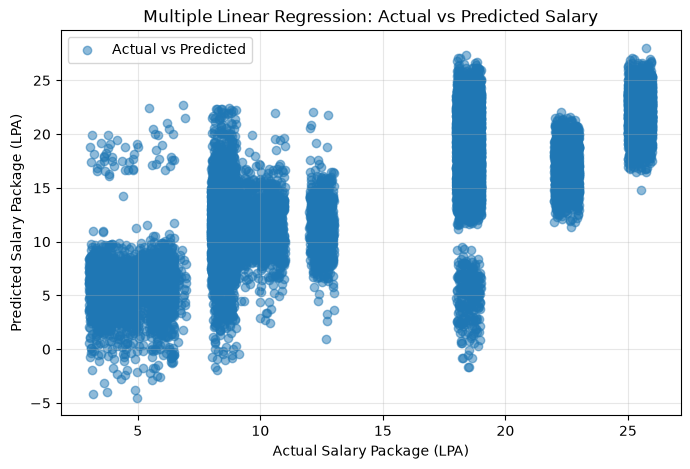

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_train,
    y_train_pred,
    alpha=0.5,
    label="Actual vs Predicted"
)

plt.xlabel("Actual Salary Package (LPA)")
plt.ylabel("Predicted Salary Package (LPA)")
plt.title("Multiple Linear Regression: Actual vs Predicted Salary")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
y_test_pred = model.predict(x_test)

In [13]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 15.654186732791352
RMSE: 3.9565372148877045
MAE : 3.220103778260847
R²  : 0.6648648578476969


In [14]:
# Sample student values (replacing interactive input for automated execution)
new_student = [[
    7.5,   # CGPA
    75.0,  # Aptitude Test Score
    4.0,   # Soft Skills Rating
    70.0,  # Coding Test Score
    80.0   # Mock Interview Score
]]

predicted_salary = model.predict(new_student)[0]
print(f"Predicted Salary Package: {predicted_salary:.2f} LPA")


Predicted Salary Package: 14.05 LPA


C:\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
